In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import time



sns.set_theme(style="whitegrid")


### Loading Data

In [49]:
df = pd.read_csv('data/Instagram_Analytics.csv')
df.head()

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,...,5,7,34,4327,6230,0.0385,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,...,10,21,68,7451,8268,0.0663,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,...,2,1,22,1639,2616,0.0531,758,115,8,high
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,...,0,7,0,2877,3171,0.0309,402,115,7,medium
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,...,8,5,21,5350,8503,0.0221,155,112,9,low


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   post_id                   29999 non-null  str    
 1   account_id                29999 non-null  int64  
 2   account_type              29999 non-null  str    
 3   follower_count            29999 non-null  int64  
 4   media_type                29999 non-null  str    
 5   content_category          29999 non-null  str    
 6   traffic_source            29999 non-null  str    
 7   has_call_to_action        29999 non-null  int64  
 8   post_datetime             29999 non-null  str    
 9   post_date                 29999 non-null  str    
 10  post_hour                 29999 non-null  int64  
 11  day_of_week               29999 non-null  str    
 12  likes                     29999 non-null  int64  
 13  comments                  29999 non-null  int64  
 14  shares           

In [51]:
df.isna().sum()

post_id                     0
account_id                  0
account_type                0
follower_count              0
media_type                  0
content_category            0
traffic_source              0
has_call_to_action          0
post_datetime               0
post_date                   0
post_hour                   0
day_of_week                 0
likes                       0
comments                    0
shares                      0
saves                       0
reach                       0
impressions                 0
engagement_rate             0
followers_gained            0
caption_length              0
hashtags_count              0
performance_bucket_label    0
dtype: int64

### Goal

Our goal is to predict "performance_bucket_label" 

Because we will be predicting *before* a post is published, data like likes and comments and shares does not matter because these things are a result of high engagement and not the predictors 

we must strictly drop all post-hoc metrics (e.g., likes, comments, reach, engagement_rate). We will also drop identifiers (like post_id) that offer no predictive mathematical value.

so we have 

post_hoc_metrics = ['likes', 'comments', 'shares', 'saves', 'reach', 'impressions', 'engagement_rate', 'followers_gained']

identifiers = ['post_id', 'account_id', 'post_datetime', 'post_date']


In [52]:


post_hoc_metrics = ['likes', 'comments', 'shares', 'saves', 'reach', 'impressions', 'engagement_rate', 'followers_gained']
identifiers = ['post_id', 'account_id', 'post_datetime', 'post_date']


df_clean = df.drop(columns=post_hoc_metrics + identifiers)

print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean.shape}")
print("\nRemaining Valid Predictors:")
print(df_clean.columns.tolist())

Original dataset shape: (29999, 23)
Cleaned dataset shape: (29999, 11)

Remaining Valid Predictors:
['account_type', 'follower_count', 'media_type', 'content_category', 'traffic_source', 'has_call_to_action', 'post_hour', 'day_of_week', 'caption_length', 'hashtags_count', 'performance_bucket_label']


### Checking for Class Imbalance
**Objective:** Evaluate the distribution of our target variable (`performance_bucket_label`). 


ML algo like Logistic Regression and Random Forests assume roughly balanced classes. If one class dominates the dataset, the model will bias its predictions toward the majority class to minimize its overall error rate. Understanding this distribution will tell us whether we need to apply class weights or not.

/tmp/ipykernel_52210/4175793198.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='performance_bucket_label', order=df_clean['performance_bucket_label'].value_counts().index, palette='viridis')


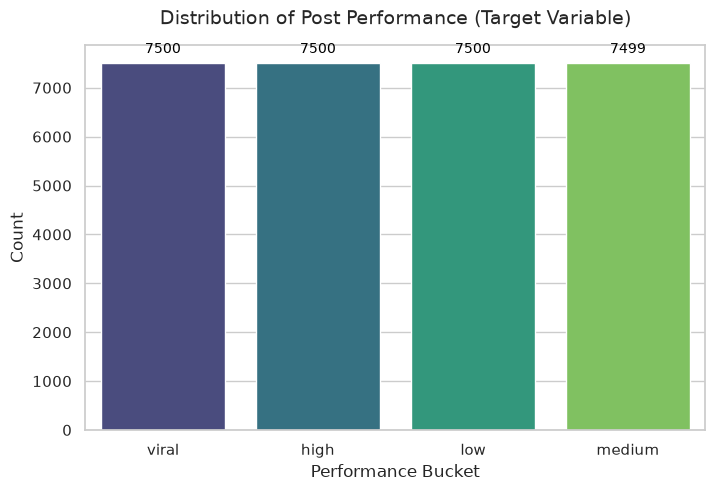

Class Distribution Percentages:
performance_bucket_label
viral     25.000833
high      25.000833
low       25.000833
medium    24.997500
Name: proportion, dtype: float64


In [53]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_clean, x='performance_bucket_label', order=df_clean['performance_bucket_label'].value_counts().index, palette='viridis')

plt.title('Distribution of Post Performance (Target Variable)', fontsize=14, pad=15)
plt.xlabel('Performance Bucket', fontsize=12)
plt.ylabel('Count', fontsize=12)


for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.show()

# Print exact percentages
print("Class Distribution Percentages:")
print(df_clean['performance_bucket_label'].value_counts(normalize=True) * 100)

here we dont need to use class weights

### Categorical Feature Impact

Now we want to see how different categorical choices (like what type of media you post) correlate with the performance bucket.

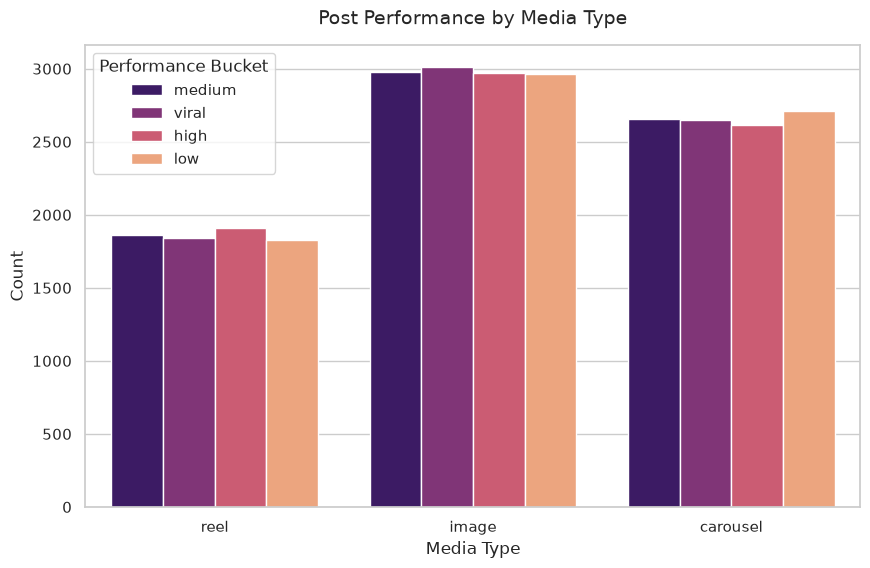

In [54]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='media_type', hue='performance_bucket_label', palette='magma')

plt.title('Post Performance by Media Type', fontsize=14, pad=15)
plt.xlabel('Media Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Performance Bucket')

plt.show()

## Continuous Feature Distributions
Next, we examine the continuous variables: `follower_count` and `caption_length`. By using boxplots, we can observe the median values, and the presence of outliers across our four performance buckets. This helps us understand if having more followers or writing longer captions correlates with higher engagement.

/tmp/ipykernel_52210/2265427251.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='performance_bucket_label', y='follower_count', palette='coolwarm', ax=axes[0])
/tmp/ipykernel_52210/2265427251.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='performance_bucket_label', y='caption_length', palette='coolwarm', ax=axes[1])


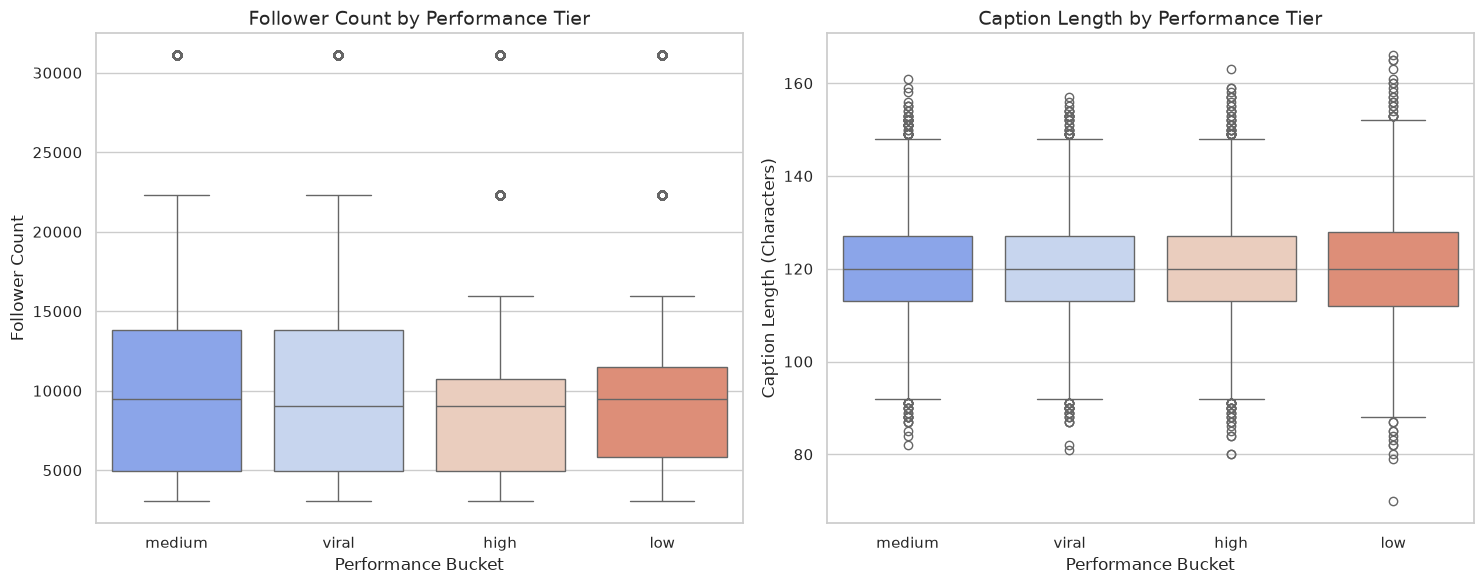

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Follower Count Boxplot
sns.boxplot(data=df_clean, x='performance_bucket_label', y='follower_count', palette='coolwarm', ax=axes[0])
axes[0].set_title('Follower Count by Performance Tier', fontsize=14)
axes[0].set_xlabel('Performance Bucket', fontsize=12)
axes[0].set_ylabel('Follower Count', fontsize=12)

# Caption Length Boxplot
sns.boxplot(data=df_clean, x='performance_bucket_label', y='caption_length', palette='coolwarm', ax=axes[1])
axes[1].set_title('Caption Length by Performance Tier', fontsize=14)
axes[1].set_xlabel('Performance Bucket', fontsize=12)
axes[1].set_ylabel('Caption Length (Characters)', fontsize=12)

plt.tight_layout()
plt.show()

## Temporal Analysis (Post Hour)
Time is a critical metadata feature. Here, we analyze the distribution of `post_hour` (0-23) to see if certain times of day yield different performance outcomes.

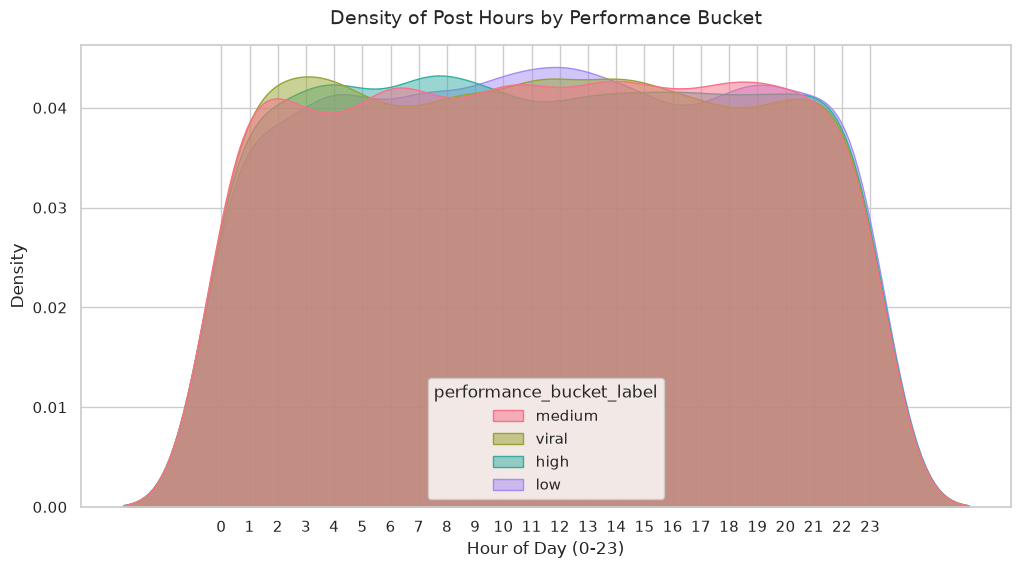

In [56]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_clean, x='post_hour', hue='performance_bucket_label', fill=True, common_norm=False, palette='husl', alpha=0.5)

plt.title('Density of Post Hours by Performance Bucket', fontsize=14, pad=15)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xticks(range(0, 24))

plt.show()

##  Cyclical Feature Engineering
Algorithms treat numbers linearly, meaning they perceive Hour 23 and Hour 0 as being 23 units apart. In reality, they are adjacent. To fix this, we map the 24-hour cycle onto a 2D circle using trigonometric transformations. 

We engineer two new features:
* $Hour_{sin} = \sin(\frac{2 \pi \cdot hour}{24})$
* $Hour_{cos} = \cos(\frac{2 \pi \cdot hour}{24})$

In [57]:
df_clean['post_hour_sin'] = np.sin(2 * np.pi * df_clean['post_hour'] / 24.0)
df_clean['post_hour_cos'] = np.cos(2 * np.pi * df_clean['post_hour'] / 24.0)

# Dropping the original column
df_clean = df_clean.drop(columns=['post_hour'])

print(df_clean[['post_hour_sin', 'post_hour_cos']].head())

   post_hour_sin  post_hour_cos
0       1.000000   6.123234e-17
1      -0.707107  -7.071068e-01
2      -0.866025  -5.000000e-01
3       0.707107   7.071068e-01
4       0.707107  -7.071068e-01


## Train / Test Split
Before applying any scaling, we must split our dataset into a Training set (80%) and a Testing set (20%). 

In [ ]:
from sklearn.model_selection import train_test_split


X = df_clean.drop(columns=['performance_bucket_label'])
y = df_clean['performance_bucket_label']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (23999, 11)
Testing features shape: (6000, 11)


## Preprocessing 
We utilize `scikit-learn`'s `ColumnTransformer` to handle different data types simultaneously:
1. **Numerical Features:** We apply `StandardScaler` to features like follower count and caption length. This transforms them to have a mean of 0 and a standard deviation of 1, ensuring stable and fast convergence for our Logistic Regression baseline.
2. **Categorical Features:** We apply `OneHotEncoder` to convert text categories (like media_type) into binary vectors. We drop the first category (`drop='first'`) to prevent multicollinearity.
3. **Pass-through:** Features that are already optimally engineered (our engineered sine/cosine times and the binary `has_call_to_action`) bypass transformation.

In [ ]:
numeric_features = ['follower_count', 'caption_length', 'hashtags_count']
categorical_features = ['account_type', 'media_type', 'content_category', 'day_of_week']
passthrough_features = ['has_call_to_action', 'post_hour_sin', 'post_hour_cos']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('pass', 'passthrough', passthrough_features)
    ])


X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names) + passthrough_features

print(f"Number of features after preprocessing: {X_train_processed.shape[1]}")

Number of features after preprocessing: 24


# Model Training & Benchmarking
We will now train three mathematically distinct classical Machine Learning algorithms to evaluate their predictive power on our structured social media metadata:

1. **Logistic Regression (Linear Baseline):** Fits linear decision boundaries by mapping the log-odds of our targets via the sigmoid activation function.
2. **Random Forest Classifier (Bagging Ensemble):** Builds multiple independent decision trees using bootstrap aggregation and votes across them to reduce variance.
3. **HistGradientBoostingClassifier (Boosting Powerhouse):** Builds trees sequentially to optimize residual errors, utilizing histogram-based binning for structural efficiency on tabular data.

In [ ]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42)
}


trained_models = {}
training_times = {}


for name, model in models.items():
    start_time = time.time()
    
    print(f"Training {name}...")
    model.fit(X_train_processed, y_train)
    
    end_time = time.time()
    training_times[name] = end_time - start_time
    trained_models[name] = model
    print(f"{name} trained successfully in {training_times[name]:.4f} seconds.\n")

Training Logistic Regression...


Logistic Regression trained successfully in 0.1228 seconds.

Training Random Forest...
Random Forest trained successfully in 3.1533 seconds.

Training Gradient Boosting...
Gradient Boosting trained successfully in 2.4205 seconds.



##  Generating Baseline Predictions
With the training phase complete, we extract both hard predictions (predicted classes) and soft predictions (probability scores) from each model using our processed test dataset. These outputs will serve as the foundation for our comparative evaluation metrics.

In [61]:
y_preds = {}
y_probs = {}


for name, model in trained_models.items():
    y_preds[name] = model.predict(X_test_processed)

    y_probs[name] = model.predict_proba(X_test_processed)

print("Predictions successfully generated for all benchmark models.")

Predictions successfully generated for all benchmark models.


# Comparative Model Evaluation
We evaluate our three models using Accuracy, Precision, Recall, and the Macro F1-Score. Because this is a multiclass problem, the Macro F1-Score ($F_1 = 2 \cdot \frac{precision \cdot recall}{precision + recall}$) is our primary metric, as it calculates the metric independently for each class and then takes the unweighted mean, treating the "Viral" class with the exact same importance as the "Low" class.

In [ ]:

results = []

for name, y_pred in y_preds.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Macro Precision": prec,
        "Macro Recall": rec,
        "Macro F1-Score": f1
    })

# Display the results as a formatted dataframe
results_df = pd.DataFrame(results).sort_values(by='Macro F1-Score', ascending=False)
display(results_df)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
2,Gradient Boosting,0.251833,0.253236,0.251833,0.249872
0,Logistic Regression,0.247333,0.247542,0.247333,0.246803
1,Random Forest,0.242333,0.242257,0.242333,0.242161


## Confusion Matrices
To understand the specific classification errors, we plot the Confusion Matrix for each model. The diagonal represents correct predictions. Off-diagonal elements show misclassifications. We want to see if the models are confusing adjacent tiers (e.g., "High" vs "Viral") or making catastrophic errors (e.g., "Low" vs "Viral").

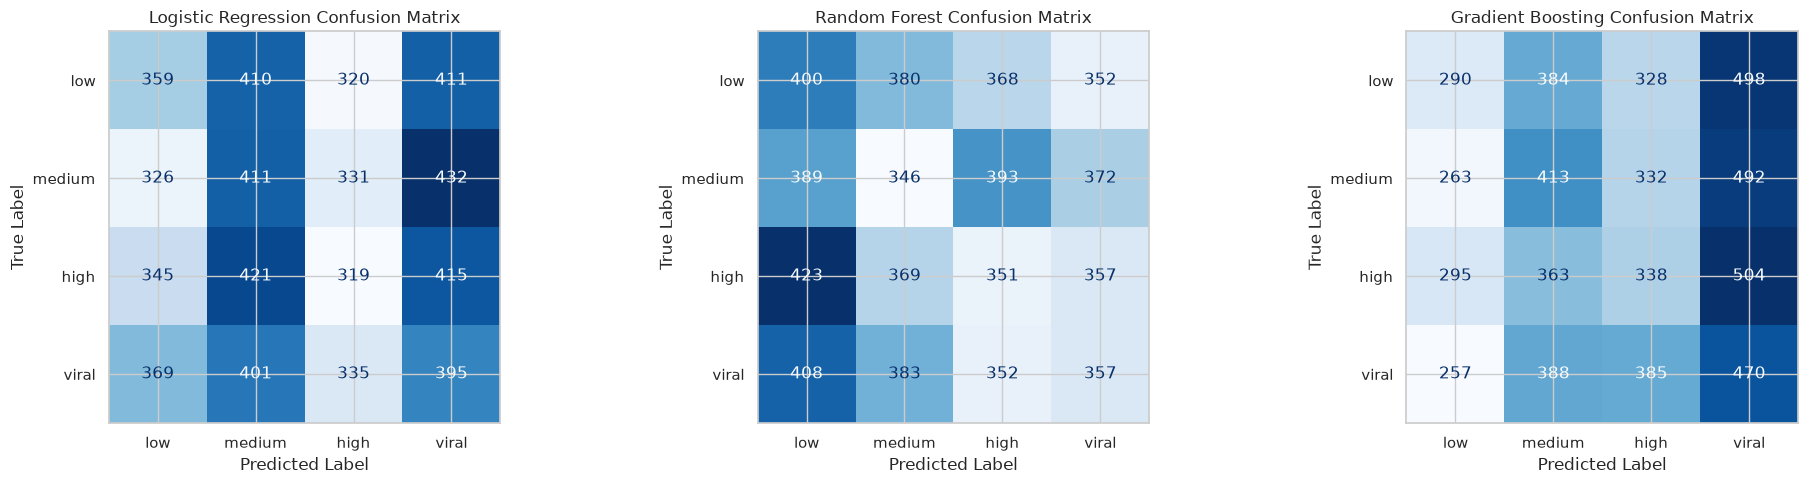

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
classes = ['low', 'medium', 'high', 'viral'] # Assuming these are your class names

for ax, (name, model) in zip(axes, trained_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test_processed, y_test,
        display_labels=classes,
        cmap='Blues',
        colorbar=False,
        ax=ax
    )
    ax.set_title(f'{name} Confusion Matrix', fontsize=12)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

## Feature Importance
A high-performing model is a black box without interpretability. To provide business insights, we extract the Feature Importance from our Random Forest model to determine which metadata fields drive post performance the most.

/tmp/ipykernel_52210/2203568690.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='viridis')


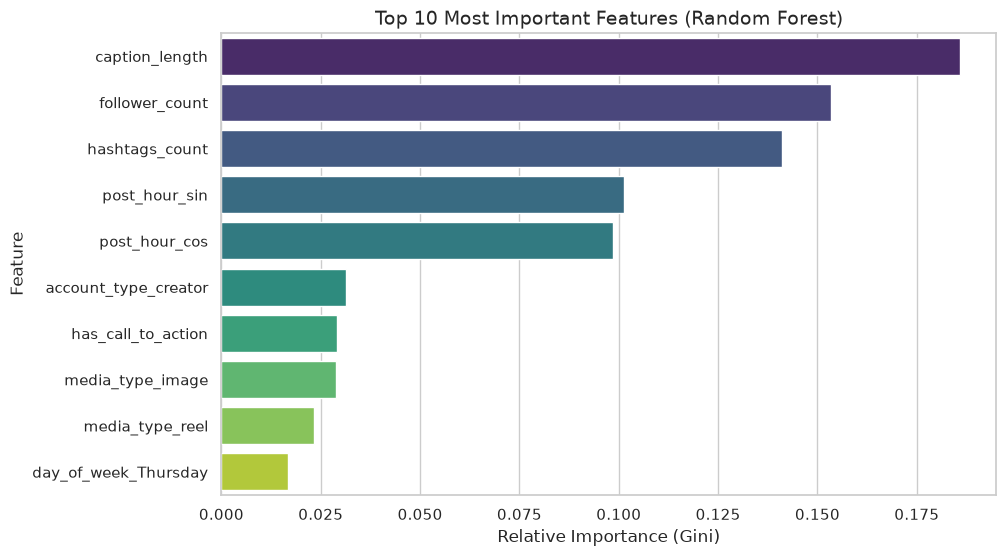

In [64]:

rf_model = trained_models['Random Forest']
importances = rf_model.feature_importances_


feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Most Important Features (Random Forest)', fontsize=14)
plt.xlabel('Relative Importance (Gini)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()